In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define tickers and date range
tickers = ['TSLA', 'BND', 'SPY']
start = '2015-01-01'
end = '2026-06-30'

# Download data
data = yf.download(tickers, start=start, end=end)

# ---- Extract close prices ----
# yfinance returns a MultiIndex; we need 'Close'
prices = data.xs('Close', axis=1, level=0)
prices.columns = ['Tesla', 'Vanguard_Bond', 'SP500']

# Save raw data
prices.to_csv('../data/processed/asset_prices.csv')
print('Data shape:', prices.shape)
prices.head()

[*********************100%***********************]  3 of 3 completed

Data shape: (2888, 3)


,Tesla,Vanguard_Bond,SP500
Date,,,
2015-01-02,59.405407,169.687866,14.620667
2015-01-05,59.577923,166.623367,14.006000
2015-01-06,59.750401,165.053925,14.085333
2015-01-07,59.786339,167.110718,14.063333
2015-01-08,59.692947,170.076111,14.041333


In [28]:
print(prices.describe())
print('\nMissing values:\n', prices.isnull().sum())
# Fill any missing with forward fill (common in finance)
prices.ffill(inplace=True)

             Tesla  Vanguard_Bond        SP500
count  2888.000000    2888.000000  2888.000000
mean     66.503052     351.505532   148.773923
std       4.713607     155.443934   138.895957
min      58.729221     154.161606     9.578000
25%      62.478091     223.546833    18.393499
50%      65.728394     312.817932   133.437668
75%      70.689154     432.806786   251.925831
max      74.832901     757.618225   489.880005

Missing values:
 Tesla            0
Vanguard_Bond    0
SP500            0
dtype: int64


,Tesla,Vanguard_Bond,SP500
Date,,,
2015-01-02,59.405407,169.687866,14.620667
2015-01-05,59.577923,166.623367,14.006000
2015-01-06,59.750401,165.053925,14.085333
2015-01-07,59.786339,167.110718,14.063333
2015-01-08,59.692947,170.076111,14.041333
...,...,...,...
2026-06-23,72.976631,733.580017,381.609985
2026-06-24,73.305534,733.239990,375.529999
2026-06-25,73.355370,734.299988,375.119995


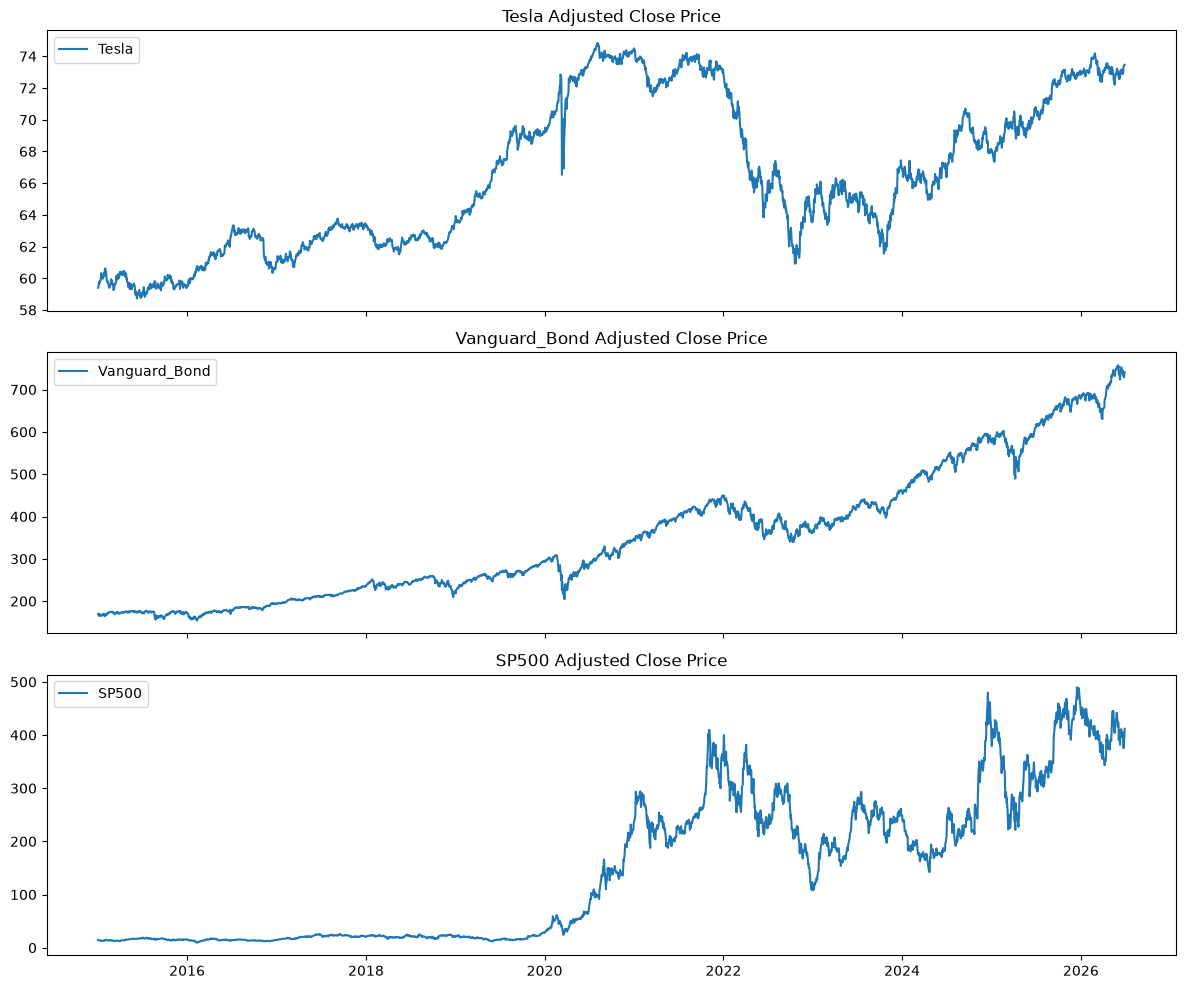

In [29]:
fig, axes = plt.subplots(3,1, figsize=(12,10), sharex=True)
for i, col in enumerate(prices.columns):
    axes[i].plot(prices.index, prices[col], label=col)
    axes[i].set_title(f'{col} Adjusted Close Price')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../reports/images/closing_prices.png', dpi=150)
plt.show()

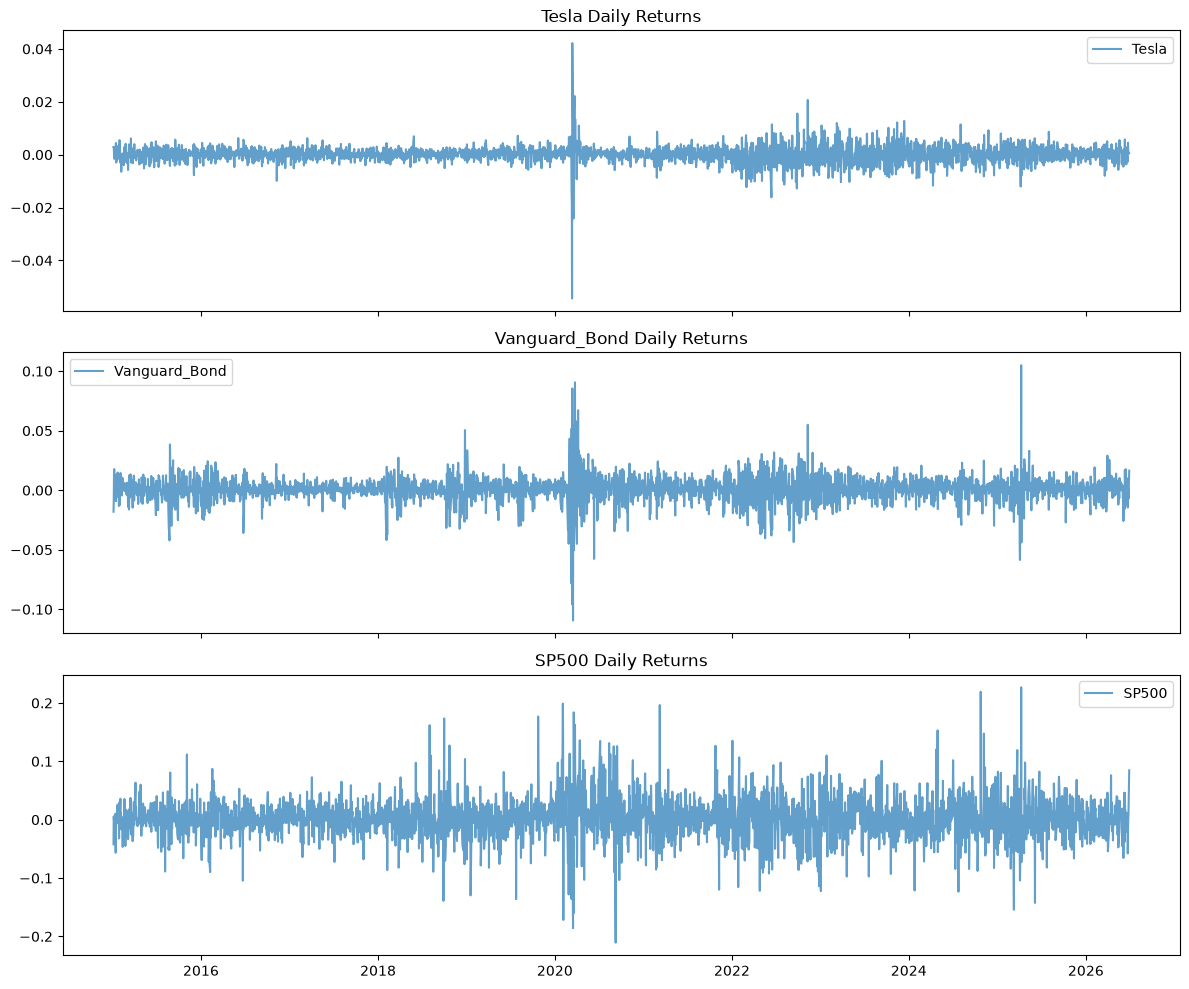

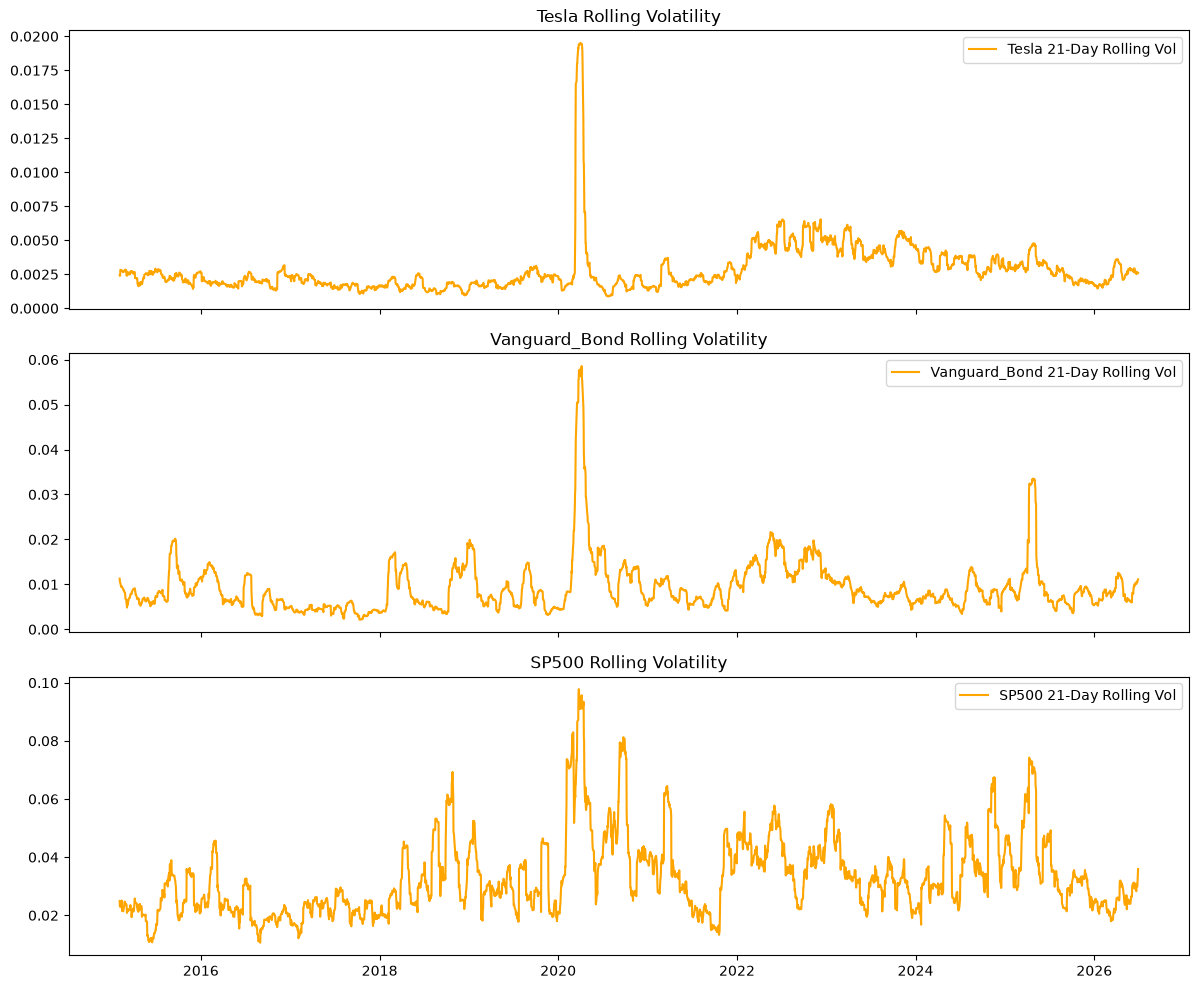

In [30]:
daily_returns = prices.pct_change().dropna()
fig, axes = plt.subplots(3,1, figsize=(12,10), sharex=True)
for i, col in enumerate(daily_returns.columns):
    axes[i].plot(daily_returns.index, daily_returns[col], label=col, alpha=0.7)
    axes[i].set_title(f'{col} Daily Returns')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../reports/images/daily_returns.png', dpi=150)
plt.show()

# Rolling volatility (21-day rolling std)
rolling_vol = daily_returns.rolling(21).std()
fig, axes = plt.subplots(3,1, figsize=(12,10), sharex=True)
for i, col in enumerate(rolling_vol.columns):
    axes[i].plot(rolling_vol.index, rolling_vol[col], label=f'{col} 21-Day Rolling Vol', color='orange')
    axes[i].set_title(f'{col} Rolling Volatility')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../reports/images/rolling_volatility.png', dpi=150)
plt.show()

In [31]:
# Identify days with returns > 3 standard deviations from mean
for col in daily_returns.columns:
    mean_ret = daily_returns[col].mean()
    std_ret = daily_returns[col].std()
    outliers = daily_returns[(daily_returns[col] > mean_ret + 3*std_ret) | 
                             (daily_returns[col] < mean_ret - 3*std_ret)]
    if not outliers.empty:
        print(f'{col} outlier dates:\n', outliers.index.strftime('%Y-%m-%d').tolist())

Tesla outlier dates:
 ['2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13', '2020-03-16', '2020-03-17', '2020-03-18', '2020-03-20', '2020-03-23', '2020-03-25', '2020-04-09', '2022-03-02', '2022-03-21', '2022-04-05', '2022-06-13', '2022-06-15', '2022-08-02', '2022-08-05', '2022-09-22', '2022-09-26', '2022-09-28', '2022-11-10', '2023-01-06', '2023-03-10', '2023-03-15', '2023-03-27', '2023-05-01', '2023-10-09', '2023-11-14', '2023-12-13', '2024-04-10', '2024-08-02', '2025-04-07']
Vanguard_Bond outlier dates:
 ['2015-08-24', '2015-08-26', '2016-06-24', '2018-02-05', '2018-02-08', '2018-12-26', '2020-02-24', '2020-02-27', '2020-03-02', '2020-03-04', '2020-03-05', '2020-03-09', '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13', '2020-03-16', '2020-03-17', '2020-03-18', '2020-03-20', '2020-03-24', '2020-03-26', '2020-04-01', '2020-04-06', '2020-06-11', '2020-09-03', '2020-10-28', '2022-04-29', '2022-05-05', '2022-05-18', '2022-06-13', '2022-06-16', '2022-08-26', '2022-09-13', '2022-11

In [32]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'{name}: ADF Statistic = {result[0]:.4f}, p-value = {result[1]:.4f}')
    if result[1] <= 0.05:
        print('  Series is stationary (reject H0)')
    else:
        print('  Series is non-stationary (fail to reject H0)')

# Test closing prices
for col in prices.columns:
    adf_test(prices[col], f'{col} Close Price')

# Test daily returns
for col in daily_returns.columns:
    adf_test(daily_returns[col], f'{col} Daily Returns')

Tesla Close Price: ADF Statistic = -1.0827, p-value = 0.7219
  Series is non-stationary (fail to reject H0)
Vanguard_Bond Close Price: ADF Statistic = 1.3089, p-value = 0.9967
  Series is non-stationary (fail to reject H0)
SP500 Close Price: ADF Statistic = -1.0696, p-value = 0.7270
  Series is non-stationary (fail to reject H0)
Tesla Daily Returns: ADF Statistic = -15.2161, p-value = 0.0000
  Series is stationary (reject H0)
Vanguard_Bond Daily Returns: ADF Statistic = -17.5722, p-value = 0.0000
  Series is stationary (reject H0)
SP500 Daily Returns: ADF Statistic = -53.9719, p-value = 0.0000
  Series is stationary (reject H0)


In [33]:
def historical_var(returns, confidence=0.95):
    return np.percentile(returns, 100 * (1 - confidence))

def sharpe_ratio(returns, risk_free_rate=0.02):
    # annualized Sharpe ratio (assuming daily returns, 252 trading days)
    mean_ret = returns.mean() * 252
    std_ret = returns.std() * np.sqrt(252)
    return (mean_ret - risk_free_rate) / std_ret

risk_free = 0.02
print('Risk Metrics (Annualized):')
for col in daily_returns.columns:
    var_95 = historical_var(daily_returns[col])
    sharpe = sharpe_ratio(daily_returns[col], risk_free)
    print(f'{col}: VaR(95%) = {var_95:.4f}, Sharpe Ratio = {sharpe:.4f}')

Risk Metrics (Annualized):
Tesla: VaR(95%) = -0.0048, Sharpe Ratio = -0.0008
Vanguard_Bond: VaR(95%) = -0.0167, Sharpe Ratio = 0.7042
SP500: VaR(95%) = -0.0517, Sharpe Ratio = 0.7595


In [34]:
tsla = prices['Tesla'].copy()
# Split into train (2015-2024) and test (2025-2026)
train = tsla[:'2024-12-31']
test = tsla['2025-01-01':'2026-06-30']
print(f'Train size: {len(train)}, Test size: {len(test)}')

Train size: 2516, Test size: 372


In [35]:
from statsmodels.tsa.arima.model import ARIMA

# ---- Fit a simple ARIMA(1,1,1) on integer index ----
tsla_int = tsla.reset_index(drop=True)
train_int = tsla_int.iloc[:len(train)]
test_int  = tsla_int.iloc[len(train):]

model_arima = ARIMA(train_int, order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

# Forecast for the test period
forecast_arima_vals = model_arima_fit.forecast(steps=len(test_int))
forecast_arima = pd.Series(forecast_arima_vals, index=test.index)

                               SARIMAX Results                                
Dep. Variable:                  Tesla   No. Observations:                 2516
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 145.295
Date:                Mon, 06 Jul 2026   AIC                           -284.589
Time:                        10:58:57   BIC                           -267.099
Sample:                             0   HQIC                          -278.241
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6096      0.102      5.956      0.000       0.409       0.810
ma.L1         -0.6474      0.101     -6.409      0.000      -0.845      -0.449
sigma2         0.0522      0.000    166.211      0.0

In [36]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Scale data
scaler = MinMaxScaler()
tsla_scaled = scaler.fit_transform(tsla.values.reshape(-1,1))

# Create sequences (60 days to predict next day)
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(tsla_scaled, seq_len)

# Split into train/test (aligned with dates)
train_len = len(train)
X_train, X_test = X[:train_len - seq_len], X[train_len - seq_len:]
y_train, y_test = y[:train_len - seq_len], y[train_len - seq_len:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, 
                         validation_data=(X_test, y_test), verbose=0)

# Predict on test set
y_pred_scaled = model_lstm.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

# Create Series with proper index
forecast_lstm = pd.Series(y_pred, index=test.index[-len(y_pred):])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [39]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---- 1. Prepare integer-indexed series ----
tsla_int = tsla.reset_index(drop=True)
train_int = tsla_int.iloc[:len(train)]
test_int  = tsla_int.iloc[len(train):]

# ---- 2. Fit ARIMA(1,1,1) ----
model = ARIMA(train_int, order=(1,1,1))
fit = model.fit()

# ---- 3. Forecast by calling predict on the exact steps we need ----
# We use predict(start, end) to avoid any ambiguity
start_idx = len(train_int)
end_idx = len(train_int) + len(test_int) - 1
forecast_vals = fit.predict(start=start_idx, end=end_idx)

# ---- 4. Build Series with date index ----
forecast_arima = pd.Series(forecast_vals.values, index=test.index)

# ---- 5. Quick sanity check ----
print("First 5 ARIMA forecasts:\n", forecast_arima.head())
print("Any NaN in ARIMA forecast?", forecast_arima.isna().any())

# ---- 6. LSTM forecast (make sure that cell has already been run) ----
# If forecast_lstm doesn't exist yet, the user must run the LSTM cell first.
# We'll assume it exists.

# ---- 7. Clean evaluation without NaN ----
def mape(actual, pred):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

# ARIMA metrics
arima_clean = pd.concat([test.rename('Actual'), forecast_arima.rename('Forecast')], axis=1).dropna()
mae_arima = mean_absolute_error(arima_clean['Actual'], arima_clean['Forecast'])
rmse_arima = np.sqrt(mean_squared_error(arima_clean['Actual'], arima_clean['Forecast']))
mape_arima = mape(arima_clean['Actual'].values, arima_clean['Forecast'].values)

# LSTM metrics (align dates)
lstm_clean = pd.concat([test.rename('Actual'), forecast_lstm.rename('Forecast')], axis=1).dropna()
mae_lstm = mean_absolute_error(lstm_clean['Actual'], lstm_clean['Forecast'])
rmse_lstm = np.sqrt(mean_squared_error(lstm_clean['Actual'], lstm_clean['Forecast']))
mape_lstm = mape(lstm_clean['Actual'].values, lstm_clean['Forecast'].values)

metrics_df = pd.DataFrame(
    {'ARIMA': [mae_arima, rmse_arima, mape_arima],
     'LSTM':  [mae_lstm, rmse_lstm, mape_lstm]},
    index=['MAE', 'RMSE', 'MAPE']
).T

print("\nModel Comparison:\n", metrics_df)
metrics_df.to_csv('../reports/metrics.csv')

First 5 ARIMA forecasts:
 Date
2025-01-02    68.048193
2025-01-03    68.048420
2025-01-06    68.048559
2025-01-07    68.048643
2025-01-08    68.048694
dtype: float64
Any NaN in ARIMA forecast? False

Model Comparison:
             MAE      RMSE      MAPE
ARIMA  3.463027  3.868774  4.786777
LSTM   0.223623  0.282529  0.314266


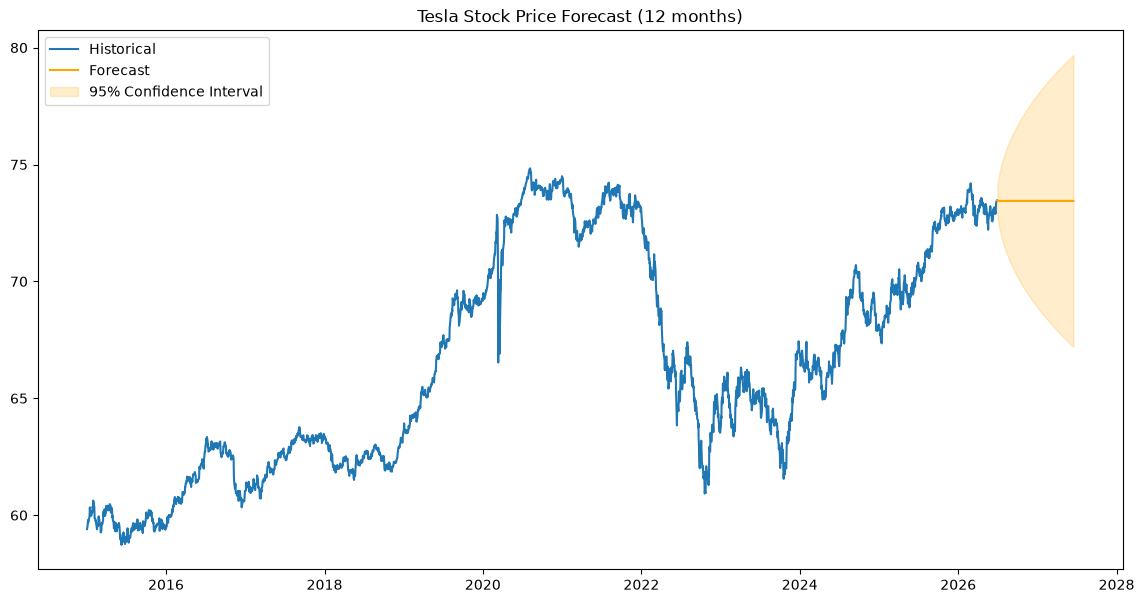

In [40]:
from statsmodels.tsa.arima.model import ARIMA

# ---- Retrain ARIMA(1,1,1) on full data (integer index) ----
full_series = tsla.reset_index(drop=True)
model_full = ARIMA(full_series, order=(1,1,1))
model_full_fit = model_full.fit()

# ---- Forecast 12 months (252 trading days) ----
forecast_horizon = 252
forecast_result = model_full_fit.get_forecast(steps=forecast_horizon)
forecast_vals = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# ---- Create future date range ----
last_date = tsla.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='B')

# ---- Convert to pandas Series with proper index ----
forecast_series = pd.Series(forecast_vals.values if hasattr(forecast_vals, 'values') else forecast_vals,
                            index=future_dates)
lower_series = pd.Series(conf_int.iloc[:,0].values if hasattr(conf_int, 'iloc') else conf_int[:,0],
                         index=future_dates)
upper_series = pd.Series(conf_int.iloc[:,1].values if hasattr(conf_int, 'iloc') else conf_int[:,1],
                         index=future_dates)

# ---- Plot ----
plt.figure(figsize=(14,7))
plt.plot(tsla, label='Historical')
plt.plot(forecast_series, label='Forecast', color='orange')
plt.fill_between(future_dates, lower_series, upper_series, alpha=0.2, color='orange', label='95% Confidence Interval')
plt.title('Tesla Stock Price Forecast (12 months)')
plt.legend()
plt.savefig('../reports/images/forecast.png', dpi=150)
plt.show()

# ---- Save forecast ----
forecast_series.to_csv('../data/processed/forecast.csv')

Expected annual returns: [-1.93250373e-04  1.44320175e-01  4.54238889e-01]


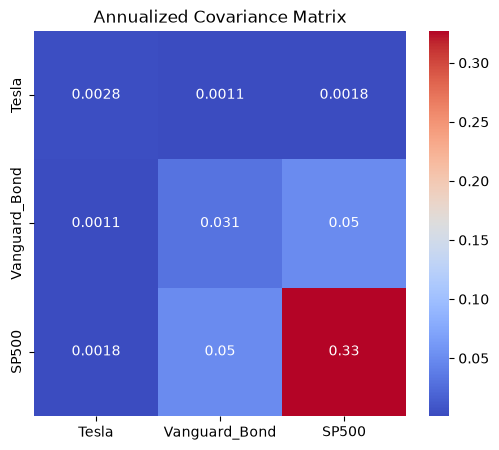

In [42]:
# Tesla expected annual return from forecast
tesla_forecast_return = (forecast_series.iloc[-1] / forecast_series.iloc[0]) ** (252/len(forecast_series)) - 1
# Historical annual returns for BND and SPY
bnd_return = daily_returns['Vanguard_Bond'].mean() * 252
spy_return = daily_returns['SP500'].mean() * 252

# Expected returns vector
exp_returns = np.array([tesla_forecast_return, bnd_return, spy_return])
print('Expected annual returns:', exp_returns)

# Covariance matrix (annualized)
cov_matrix = daily_returns.cov() * 252
cov_matrix.to_csv('../data/processed/covariance.csv')
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm')
plt.title('Annualized Covariance Matrix')
plt.savefig('../reports/images/covariance_heatmap.png', dpi=150)
plt.show()

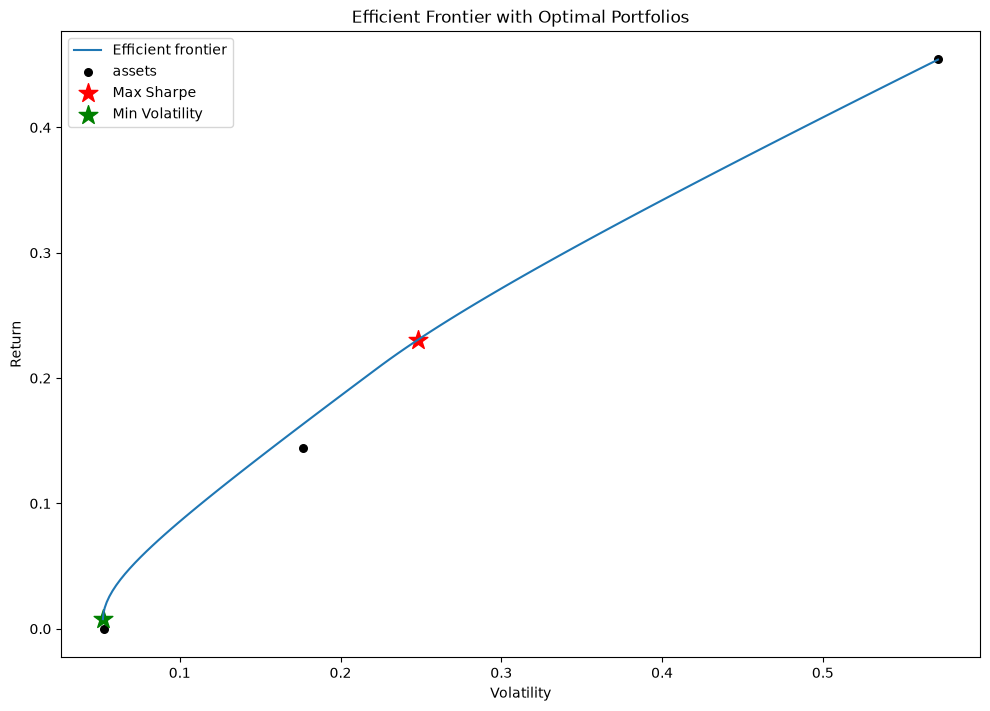

Max Sharpe Portfolio:


KeyError: 0

In [44]:
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.plotting import plot_efficient_frontier

# Use the computed expected returns and covariance
ef = EfficientFrontier(exp_returns, cov_matrix)

# Generate random portfolios for the frontier
fig, ax = plt.subplots(figsize=(10,7))
plot_efficient_frontier(ef, ax=ax, show_assets=True)
# Find tangency portfolio (max Sharpe)
ef_tangent = EfficientFrontier(exp_returns, cov_matrix)
weights_tangent = ef_tangent.max_sharpe(risk_free_rate=0.02)
ret_tangent, vol_tangent, sharpe_tangent = ef_tangent.portfolio_performance(risk_free_rate=0.02)
ax.scatter(vol_tangent, ret_tangent, marker='*', color='red', s=200, label='Max Sharpe')

# Minimum volatility portfolio
ef_minvol = EfficientFrontier(exp_returns, cov_matrix)
weights_minvol = ef_minvol.min_volatility()
ret_minvol, vol_minvol, _ = ef_minvol.portfolio_performance()
ax.scatter(vol_minvol, ret_minvol, marker='*', color='green', s=200, label='Min Volatility')

ax.legend()
plt.title('Efficient Frontier with Optimal Portfolios')
plt.savefig('../reports/images/efficient_frontier.png', dpi=150)
plt.show()

# Compile recommendation
print('Max Sharpe Portfolio:')
print(f'Weights: TSLA {weights_tangent[0]:.2%}, BND {weights_tangent[1]:.2%}, SPY {weights_tangent[2]:.2%}')
print(f'Return: {ret_tangent:.2%}, Vol: {vol_tangent:.2%}, Sharpe: {sharpe_tangent:.4f}')

Strategy weights: [0.         0.72141162 0.27858838]
bt_returns shape: (249, 3)


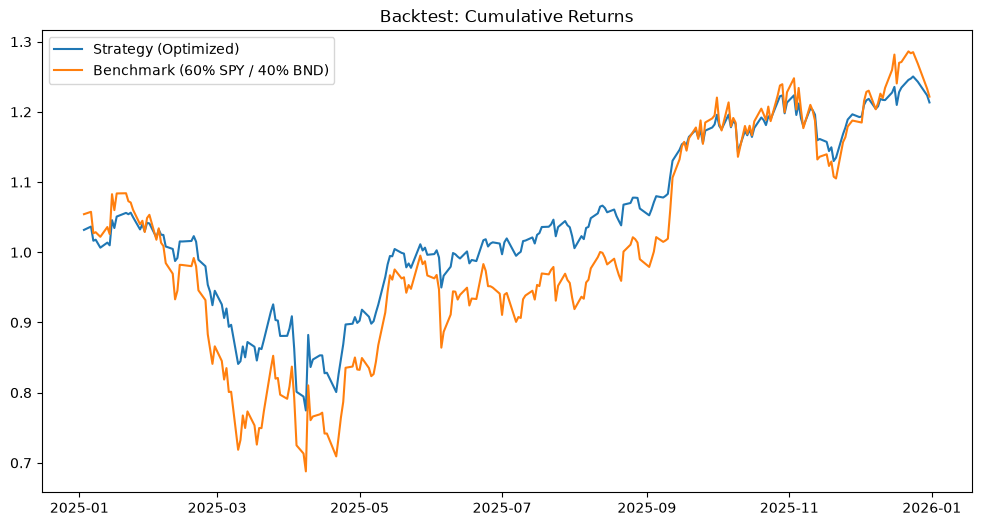

                 Strategy  Benchmark
Total Return     0.213487   0.221738
Ann. Return      0.216319   0.224690
Ann. Volatility  0.291725   0.437236
Sharpe Ratio     0.672960   0.468145
Max Drawdown    -0.266741  -0.365508


In [46]:
# Backtest period: 2025-01-01 to 2025-12-31
backtest_start = '2025-01-01'
backtest_end = '2025-12-31'
bt_prices = prices.loc[backtest_start:backtest_end]

# Daily returns of assets
bt_returns = bt_prices.pct_change().dropna()

# ---- Strategy weights from the tangency portfolio (extract values from dict) ----
strategy_weights = np.array(list(weights_tangent.values()))
benchmark_weights = np.array([0.0, 0.4, 0.6])   # 0% TSLA, 40% BND, 60% SPY

print("Strategy weights:", strategy_weights)
print("bt_returns shape:", bt_returns.shape)

# Compute portfolio returns
strategy_port_return = bt_returns.dot(strategy_weights)
benchmark_port_return = bt_returns.dot(benchmark_weights)

# Cumulative returns
strategy_cum = (1 + strategy_port_return).cumprod()
benchmark_cum = (1 + benchmark_port_return).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_cum, label='Strategy (Optimized)')
plt.plot(benchmark_cum, label='Benchmark (60% SPY / 40% BND)')
plt.title('Backtest: Cumulative Returns')
plt.legend()
plt.savefig('../reports/images/backtest.png', dpi=150)
plt.show()

# Performance metrics
def backtest_metrics(returns, risk_free_rate=0.02):
    total_return = (1 + returns).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    cum = (1 + returns).cumprod()
    peak = cum.expanding().max()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()
    return total_return, ann_return, ann_vol, sharpe, max_dd

strat_tot, strat_ann, strat_vol, strat_sharpe, strat_mdd = backtest_metrics(strategy_port_return)
bench_tot, bench_ann, bench_vol, bench_sharpe, bench_mdd = backtest_metrics(benchmark_port_return)

backtest_results = pd.DataFrame({
    'Strategy': [strat_tot, strat_ann, strat_vol, strat_sharpe, strat_mdd],
    'Benchmark': [bench_tot, bench_ann, bench_vol, bench_sharpe, bench_mdd]
}, index=['Total Return', 'Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown'])
print(backtest_results)
backtest_results.to_csv('../reports/backtest_results.csv')